# EDA First Batch

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from instanteda import eda

# Import 2, 3, 4, 5, 6 sheet from the excel file
# Define the path to the Excel file
excel_file = os.path.join('..', 'data', 'Bloomberg_first_batch.xlsx')

# List of sheet indices to import (2nd to 6th sheet: indices 1 to 5)
sheet_indices = list(range(0, 8))

# Read the sheets into a list of DataFrames
sheets = pd.read_excel(excel_file, sheet_name=sheet_indices)

bonds_df = sheets[3]
fixed_fields_df = sheets[4]
price_df = sheets[5]
bid_df = sheets[6]
ask_df = sheets[7]

## Bonds V2 Sheet

In [2]:
bonds_df = bonds_df[bonds_df['isit_good)'] == 1]
bonds_df.drop(columns=['DateOver2025', 'Is 789', 'Unnamed: 16', 'isit_good)'], inplace=True)

/var/folders/pd/p6wbrsxj001b9dpkltbn2mxh0000gn/T/ipykernel_98770/2003440773.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bonds_df.drop(columns=['DateOver2025', 'Is 789', 'Unnamed: 16', 'isit_good)'], inplace=True)


In [3]:
bonds_df.head()

,Issuer Name,Ticker,CUSIP,Bid Price,Ask Price,Amt Out,Cpn,Maturity,Series,BBG Composite,Mty Type,Currency,Mac Dur (Ask),Date
13,Abu Dhabi National Energy Co PJSC,TAQAUH,ZK2432019,100.377,100.583,500000000,4.375,1/24/2029,REGS,AA-,AT MATURITY,USD,2.719524,4/24/23
18,AIG SunAmerica Global Financing X,CRBG,EC5379283,110.447,110.672,750000000,6.900,3/15/2032,REGS,A,AT MATURITY,USD,4.941951,3/20/02
27,ANZ New Zealand Int'l Ltd/London,ANZNZ,00182FBJ4,99.047,99.106,500000000,3.450,1/21/2028,REGS,A+,AT MATURITY,USD,1.824424,1/23/18
31,ANZ New Zealand Int'l Ltd/London,ANZNZ,00182FBM7,94.327,94.463,750000000,2.550,2/13/2030,REGS,A+,AT MATURITY,USD,3.758013,2/13/20
59,Athene Global Funding,ATH,04686E3X8,100.987,101.042,550000000,5.339,1/15/2027,REGS,A+,AT MATURITY,USD,0.845410,1/17/24


In [201]:
print(bonds_df.info())
print("="*100)
print(bonds_df.describe().T)
print("="*100)
print(bonds_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 233 entries, 13 to 2671
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Issuer Name    233 non-null    object 
 1   Ticker         233 non-null    object 
 2   CUSIP          233 non-null    object 
 3   Bid Price      233 non-null    float64
 4   Ask Price      233 non-null    float64
 5   Amt Out        233 non-null    int64  
 6   Cpn            233 non-null    float64
 7   Maturity       233 non-null    object 
 8   Series         233 non-null    object 
 9   BBG Composite  233 non-null    object 
 10  Mty Type       233 non-null    object 
 11  Currency       233 non-null    object 
 12  Mac Dur (Ask)  233 non-null    float64
 13  Date           233 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 27.3+ KB
None
               count          mean           std           min           25%  \
Bid Price      233.0  1.006292e+02  5.856751e+

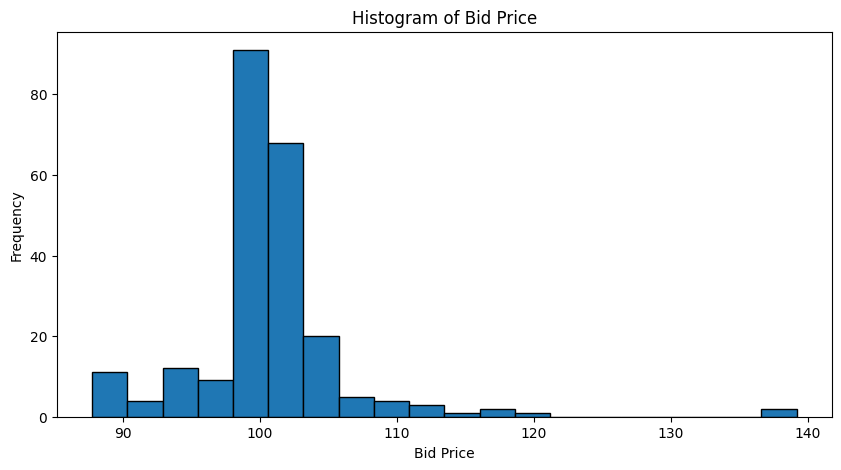

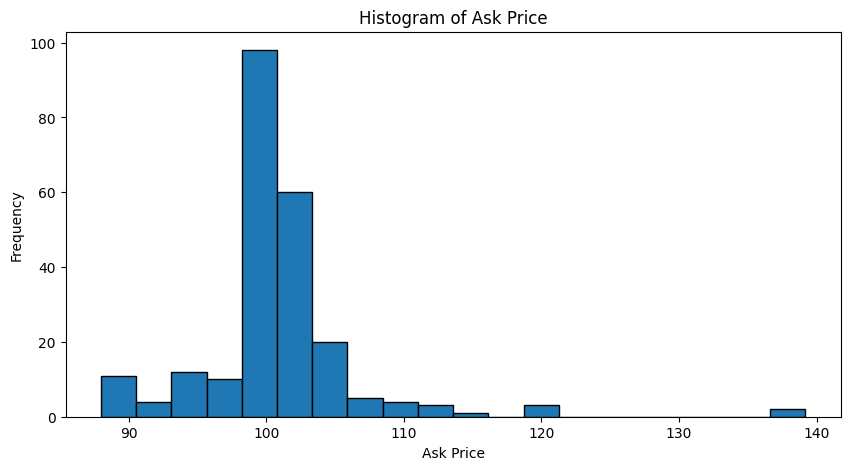

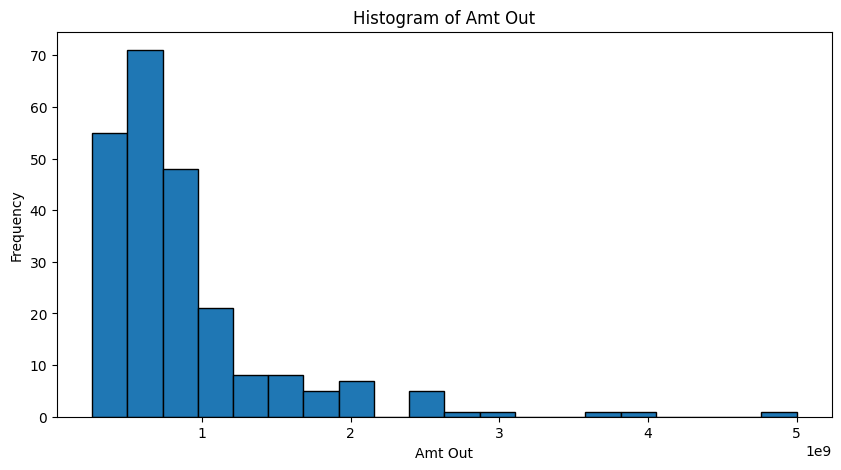

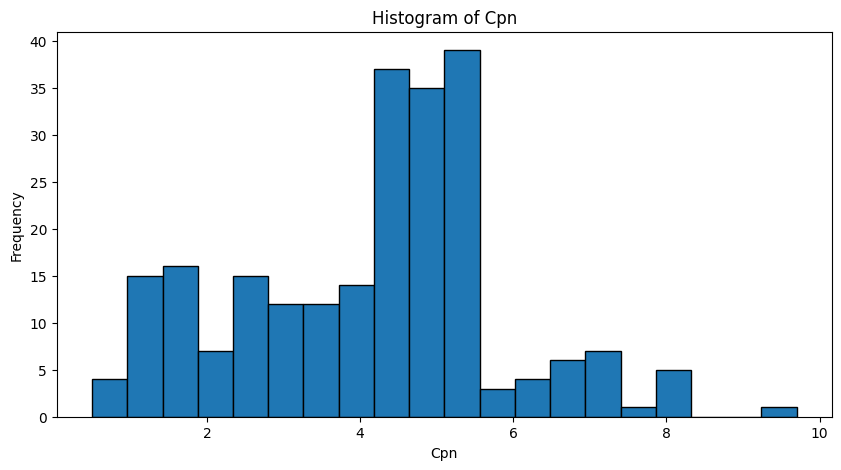

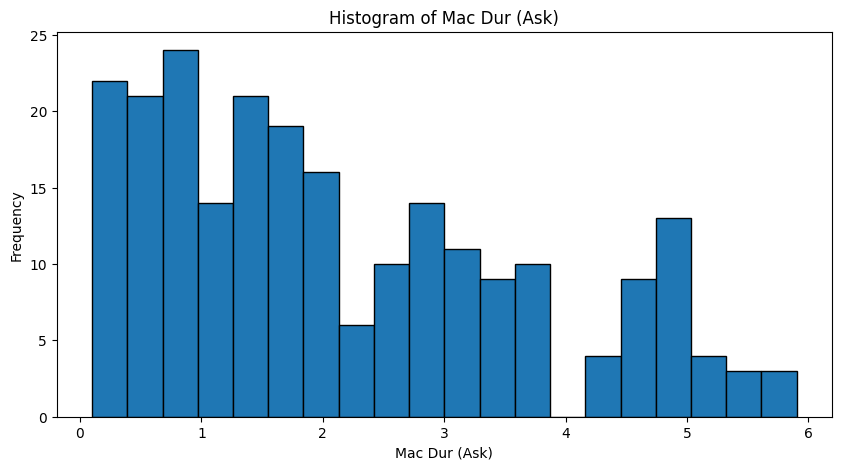

In [202]:
# Plot histograms of Bid Price and Ask Price
plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Bid Price'], bins=20, edgecolor='black')
plt.title('Histogram of Bid Price')
plt.xlabel('Bid Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Ask Price'], bins=20, edgecolor='black')
plt.title('Histogram of Ask Price')
plt.xlabel('Ask Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Amt Out'], bins=20, edgecolor='black')
plt.title('Histogram of Amt Out')
plt.xlabel('Amt Out')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Cpn'], bins=20, edgecolor='black')
plt.title('Histogram of Cpn')
plt.xlabel('Cpn')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(bonds_df['Mac Dur (Ask)'], bins=20, edgecolor='black')
plt.title('Histogram of Mac Dur (Ask)')
plt.xlabel('Mac Dur (Ask)')
plt.ylabel('Frequency')
plt.show()

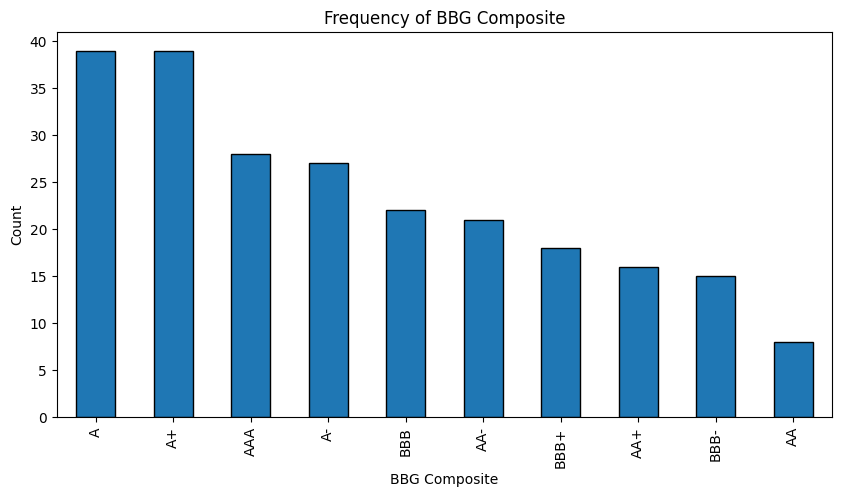

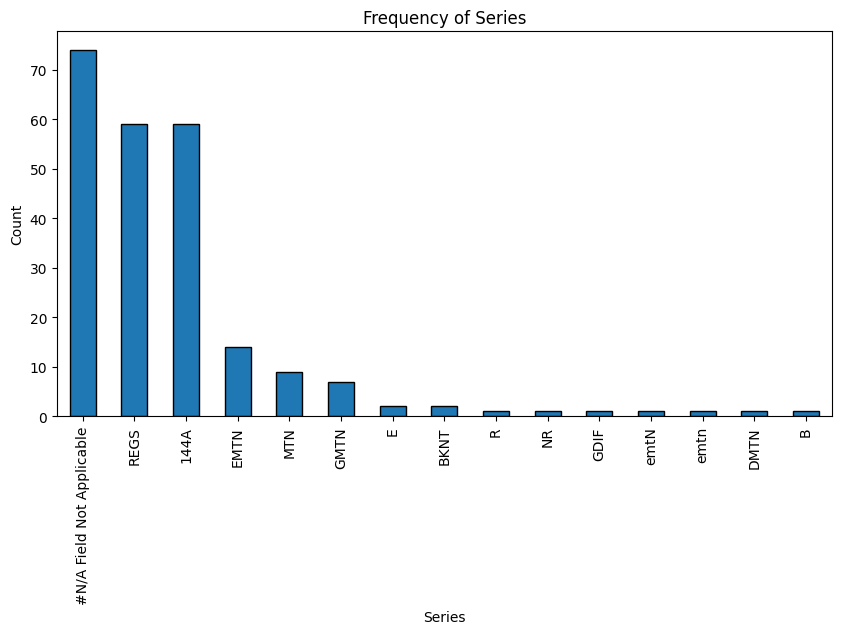

In [203]:
plt.figure(figsize=(10, 5))
bonds_df['BBG Composite'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of BBG Composite')
plt.xlabel('BBG Composite')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
bonds_df['Series'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of Series')
plt.xlabel('Series')
plt.ylabel('Count')
plt.show()

/var/folders/pd/p6wbrsxj001b9dpkltbn2mxh0000gn/T/ipykernel_53460/1046642991.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bonds_df['Date'] = pd.to_datetime(bonds_df['Date'])
/var/folders/pd/p6wbrsxj001b9dpkltbn2mxh0000gn/T/ipykernel_53460/1046642991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bonds_df['Date'] = pd.to_datetime(bonds_df['Date'])


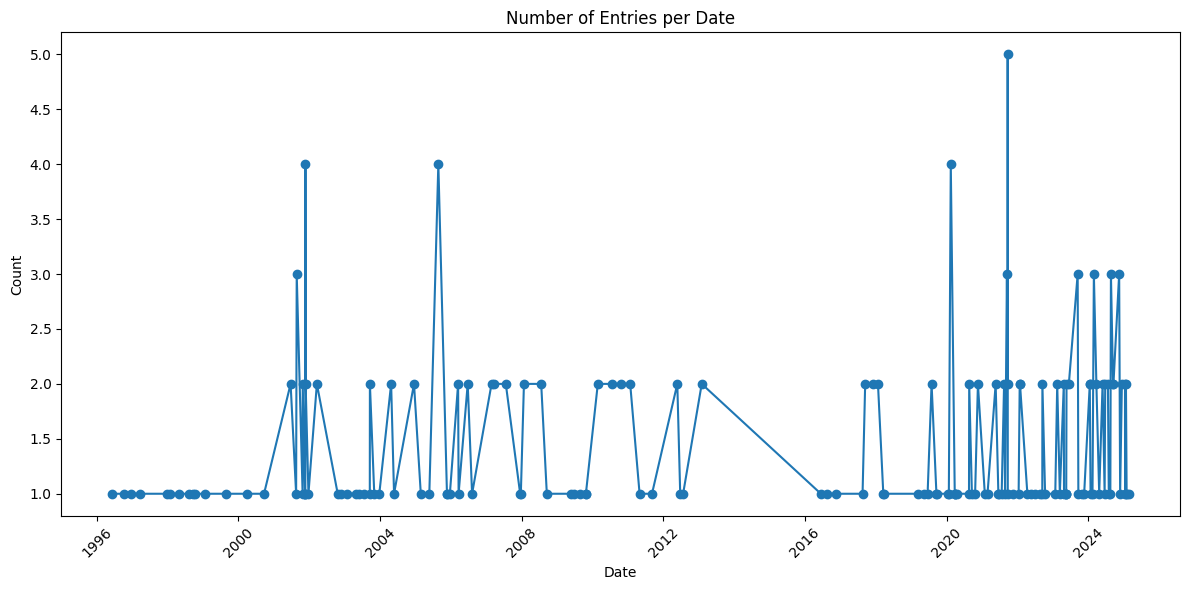

/var/folders/pd/p6wbrsxj001b9dpkltbn2mxh0000gn/T/ipykernel_53460/1046642991.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bonds_df['Maturity'] = pd.to_datetime(bonds_df['Maturity'])


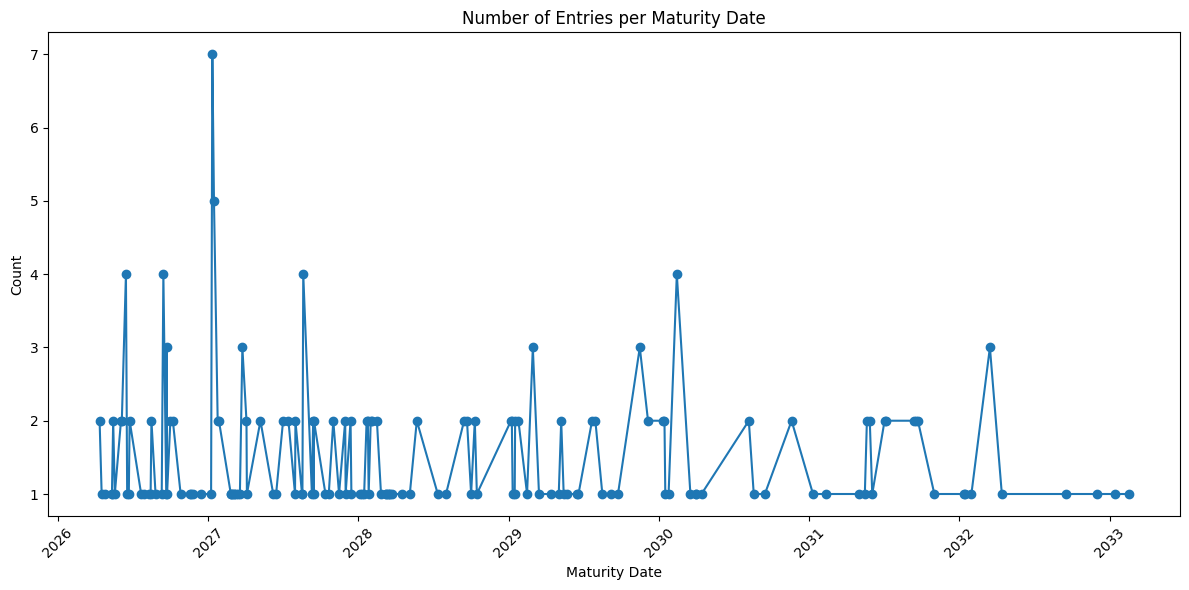

In [204]:
# Convert the 'Date' column to datetime if it's not already
bonds_df['Date'] = pd.to_datetime(bonds_df['Date'])

# Group by date and count the number of entries per date
date_counts = bonds_df['Date'].value_counts().sort_index()

# Plot line from min to max date with count on y axis
plt.figure(figsize=(12, 6))
plt.plot(date_counts.index, date_counts.values, marker='o', linestyle='-')
plt.title('Number of Entries per Date')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Convert the 'Date' column to datetime if it's not already
bonds_df['Maturity'] = pd.to_datetime(bonds_df['Maturity'])

# Group by date and count the number of entries per date
date_counts = bonds_df['Maturity'].value_counts().sort_index()

# Plot line from min to max date with count on y axis
plt.figure(figsize=(12, 6))
plt.plot(date_counts.index, date_counts.values, marker='o', linestyle='-')
plt.title('Number of Entries per Maturity Date')
plt.xlabel('Maturity Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Fixed Fields Sheet

In [205]:
fixed_fields_df.head()

,CUSIP,ISSUER,MATURITY,CPN,CPN_FREQ,RTG_MOODY,BICS_LEVEL_1_SECTOR_NAME,BICS_LEVEL_2_INDUSTRY_GROUP_NAME,DUR_ADJ_MID
0,BY6616951,ABU DHABI COMMERCIAL BNK,9/14/2027,4.500,2,NaN,Financials,Banks,1.419113
1,00388WAL5,ABU DHABI NATIONAL ENERG,1/24/2029,4.375,2,Aa3,Utilities,Power Generation,2.672048
2,ZK2432019,ABU DHABI NATIONAL ENERG,1/24/2029,4.375,2,Aa3,Utilities,Power Generation,2.663895
3,00440FAA2,ACE CAPITAL TRUST II,4/1/2030,9.700,2,A3,Financials,Property & Casualty Insurance,3.325705
4,0010EPAF5,AEP TEXAS INC,2/15/2033,6.650,2,Baa3,Utilities,Utilities,5.590289


In [206]:
print(fixed_fields_df.info())
print("="*100)
print(fixed_fields_df.describe().T)
print("="*100)
print(fixed_fields_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUSIP                             237 non-null    object 
 1   ISSUER                            237 non-null    object 
 2   MATURITY                          237 non-null    object 
 3   CPN                               237 non-null    float64
 4   CPN_FREQ                          237 non-null    int64  
 5   RTG_MOODY                         229 non-null    object 
 6   BICS_LEVEL_1_SECTOR_NAME          237 non-null    object 
 7   BICS_LEVEL_2_INDUSTRY_GROUP_NAME  237 non-null    object 
 8   DUR_ADJ_MID                       237 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 16.8+ KB
None
             count      mean       std       min      25%       50%       75%  \
CPN          237.0  4.163477  1.708105  0.500000  2.99

In [207]:
# Look at which CUSIP are in fixed_fields_df but not in bonds_df
print("CUSIPs in fixed_fields_df but not in bonds_df:")
print(fixed_fields_df[~fixed_fields_df['CUSIP'].isin(bonds_df['CUSIP'])])
# Look at which CUSIP are in bonds_df but not in fixed_fields_df
print("CUSIPs in bonds_df but not in fixed_fields_df:")
print(bonds_df[~bonds_df['CUSIP'].isin(fixed_fields_df['CUSIP'])])

CUSIPs in fixed_fields_df but not in bonds_df:
Empty DataFrame
Columns: [CUSIP, ISSUER, MATURITY, CPN, CPN_FREQ, RTG_MOODY, BICS_LEVEL_1_SECTOR_NAME, BICS_LEVEL_2_INDUSTRY_GROUP_NAME, DUR_ADJ_MID]
Index: []
CUSIPs in bonds_df but not in fixed_fields_df:
Empty DataFrame
Columns: [Issuer Name, Ticker, CUSIP, Bid Price, Ask Price, Amt Out, Cpn, Maturity, Series, BBG Composite, Mty Type, Currency, Mac Dur (Ask), Date]
Index: []


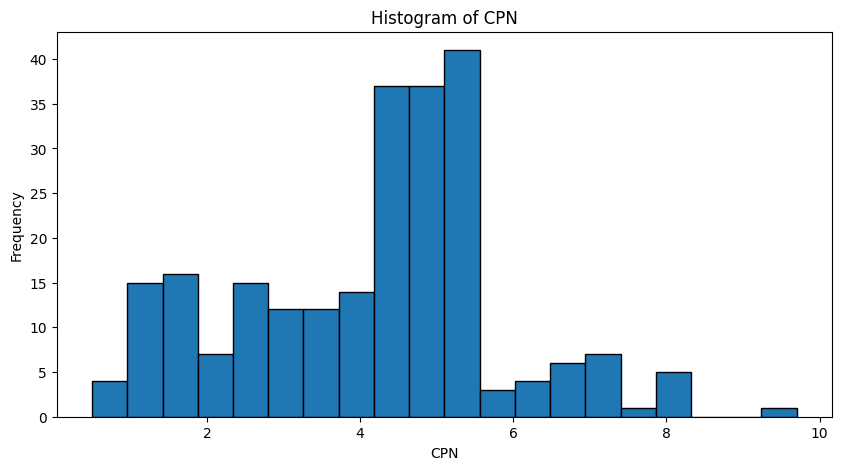

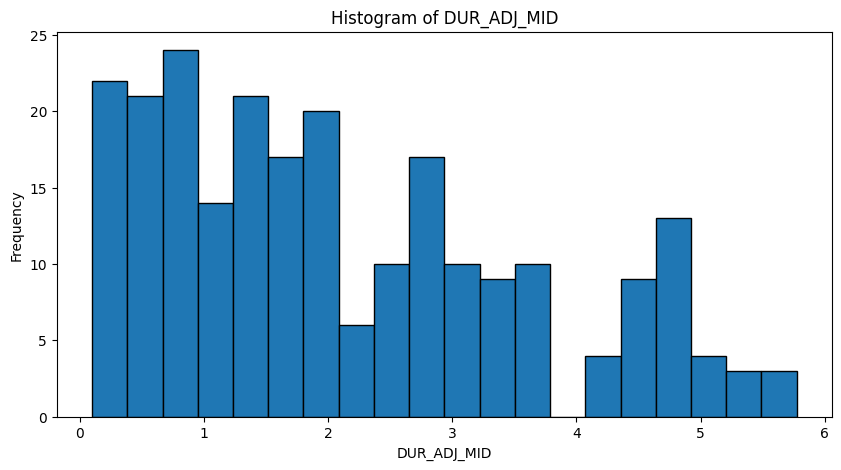

In [208]:
plt.figure(figsize=(10, 5))
plt.hist(fixed_fields_df['CPN'], bins=20, edgecolor='black')
plt.title('Histogram of CPN')
plt.xlabel('CPN')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(fixed_fields_df['DUR_ADJ_MID'], bins=20, edgecolor='black')
plt.title('Histogram of DUR_ADJ_MID')
plt.xlabel('DUR_ADJ_MID')
plt.ylabel('Frequency')
plt.show()

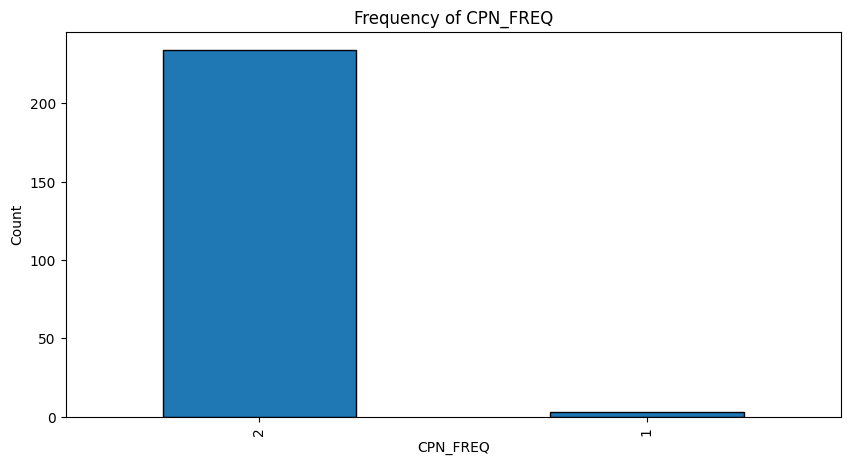

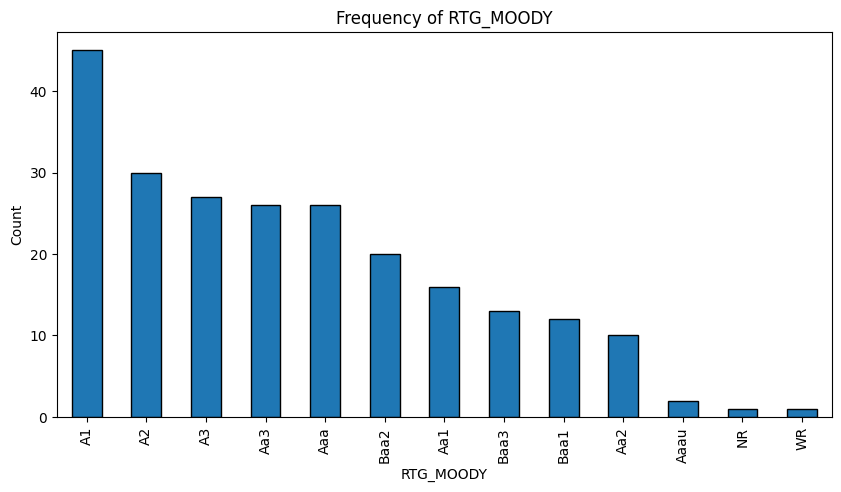

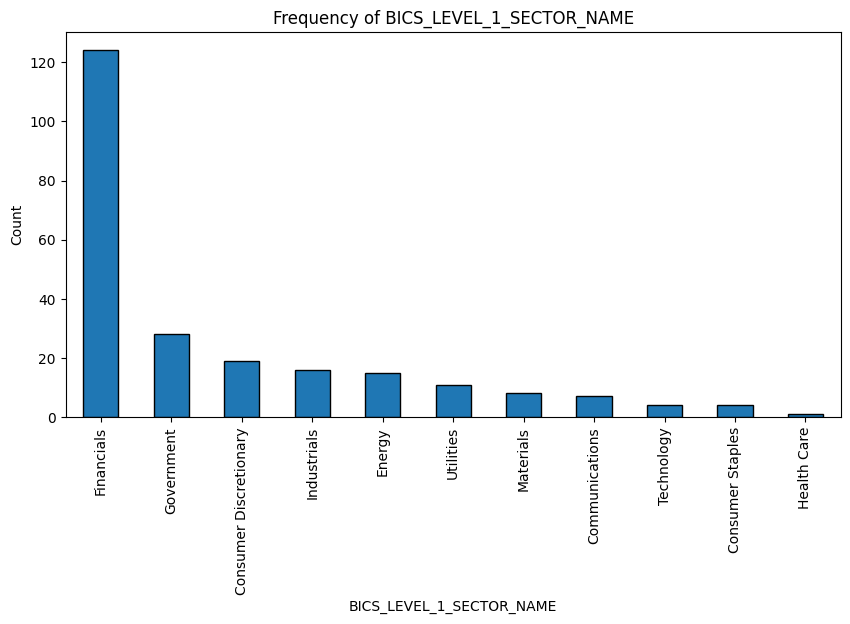

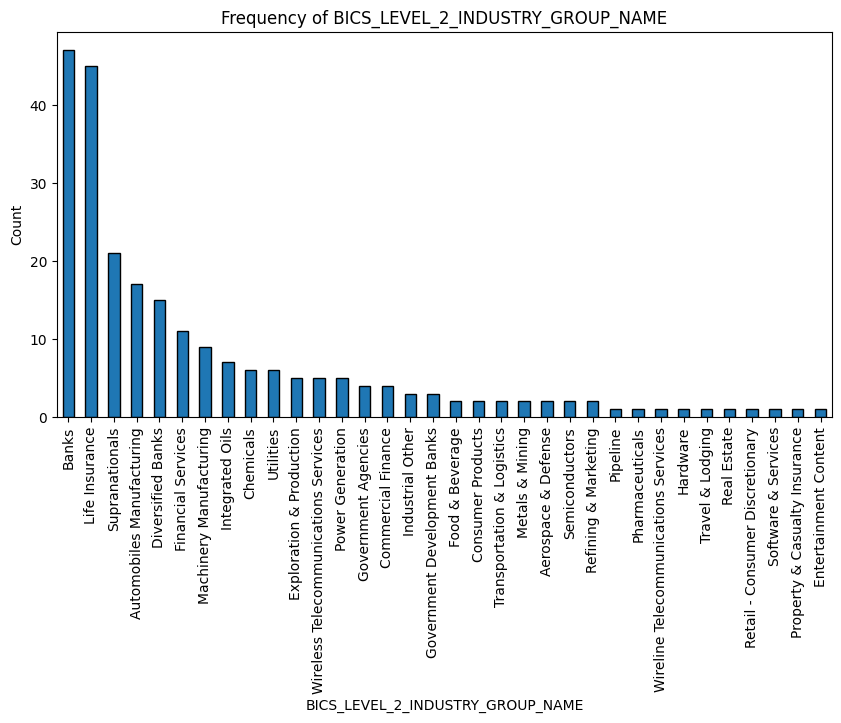

In [209]:
plt.figure(figsize=(10, 5))
fixed_fields_df['CPN_FREQ'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of CPN_FREQ')
plt.xlabel('CPN_FREQ')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
fixed_fields_df['RTG_MOODY'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of RTG_MOODY')
plt.xlabel('RTG_MOODY')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
fixed_fields_df['BICS_LEVEL_1_SECTOR_NAME'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of BICS_LEVEL_1_SECTOR_NAME')
plt.xlabel('BICS_LEVEL_1_SECTOR_NAME')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
fixed_fields_df['BICS_LEVEL_2_INDUSTRY_GROUP_NAME'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Frequency of BICS_LEVEL_2_INDUSTRY_GROUP_NAME')
plt.xlabel('BICS_LEVEL_2_INDUSTRY_GROUP_NAME')
plt.ylabel('Count')
plt.show()

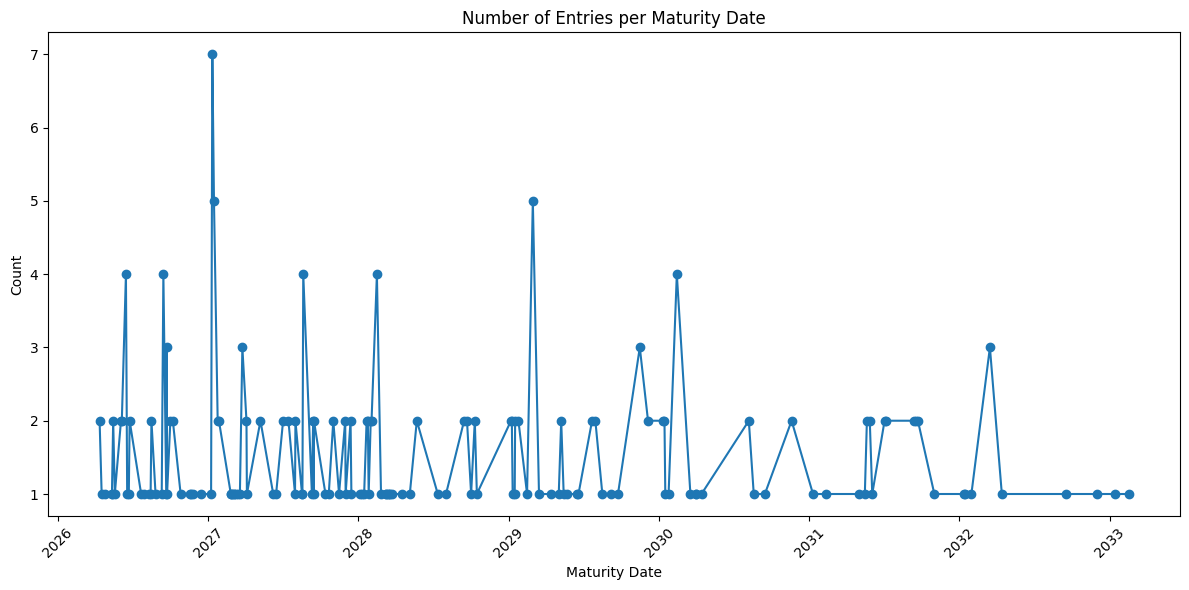

In [210]:
# Convert the 'Date' column to datetime if it's not already
fixed_fields_df['MATURITY'] = pd.to_datetime(fixed_fields_df['MATURITY'])

# Group by date and count the number of entries per date
date_counts = fixed_fields_df['MATURITY'].value_counts().sort_index()

# Plot line from min to max date with count on y axis
plt.figure(figsize=(12, 6))
plt.plot(date_counts.index, date_counts.values, marker='o', linestyle='-')
plt.title('Number of Entries per Maturity Date')
plt.xlabel('Maturity Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Price Sheet

In [211]:
price_df.head()

,Unnamed: 0,BY6616951,00388WAL5,ZK2432019,00440FAA2,0010EPAF5,00828EEF2,00828EEZ8,00139PAA6,EC5379283,...,96122XAQ1,96122WAQ3,96122QAC7,96122FAC1,96122QAA1,96122FAA5,96122QAC7.1,96122FAC1.1,96122QAA1.1,96122FAA5.1
0,2024-03-01,98.363,97.662,97.662,118.180,107.758,96.842,99.099,109.416,109.416,...,98.106,98.106,100.385,100.385,99.437,99.437,100.385,100.385,99.437,99.437
1,2024-03-04,98.272,97.668,97.668,118.702,107.246,96.862,98.921,109.103,109.103,...,97.994,97.994,100.203,100.203,99.351,99.351,100.203,100.203,99.351,99.351
2,2024-03-05,98.344,97.819,97.819,118.400,107.759,96.876,99.024,109.384,109.384,...,98.190,98.190,100.518,100.518,99.550,99.550,100.518,100.518,99.550,99.550
3,2024-03-06,98.405,97.838,97.838,118.784,107.911,96.908,99.047,109.964,109.964,...,98.170,98.170,100.643,100.643,99.713,99.713,100.643,100.643,99.713,99.713
4,2024-03-07,98.529,98.032,98.032,118.744,108.496,97.722,99.216,109.888,109.888,...,98.309,98.309,100.880,100.880,99.822,99.822,100.880,100.880,99.822,99.822


In [212]:
# Remove columns whose last (non-null) value is not at the last row index (latest date)
last_date = price_df.index[-1]
cols_to_keep = [col for col in price_df.columns if price_df[col].last_valid_index() == last_date]
price_df = price_df[cols_to_keep]

Price DF shape: (499, 149)
Price DF columns: Index(['Unnamed: 0', 'BY6616951', '00388WAL5', 'ZK2432019', '00440FAA2',
       '0010EPAF5', '00139PAA6', 'EC5379283', '00182EBJ7', '00182FBJ4',
       ...
       '96122XAQ1', '96122WAQ3', '96122QAC7', '96122FAC1', '96122QAA1',
       '96122FAA5', '96122QAC7.1', '96122FAC1.1', '96122QAA1.1',
       '96122FAA5.1'],
      dtype='object', length=149)
Missing values per column:
Unnamed: 0     0
BY6616951      0
00388WAL5      0
ZK2432019      0
00440FAA2      0
              ..
96122FAA5      0
96122QAC7.1    0
96122FAC1.1    0
96122QAA1.1    0
96122FAA5.1    0
Length: 149, dtype: int64


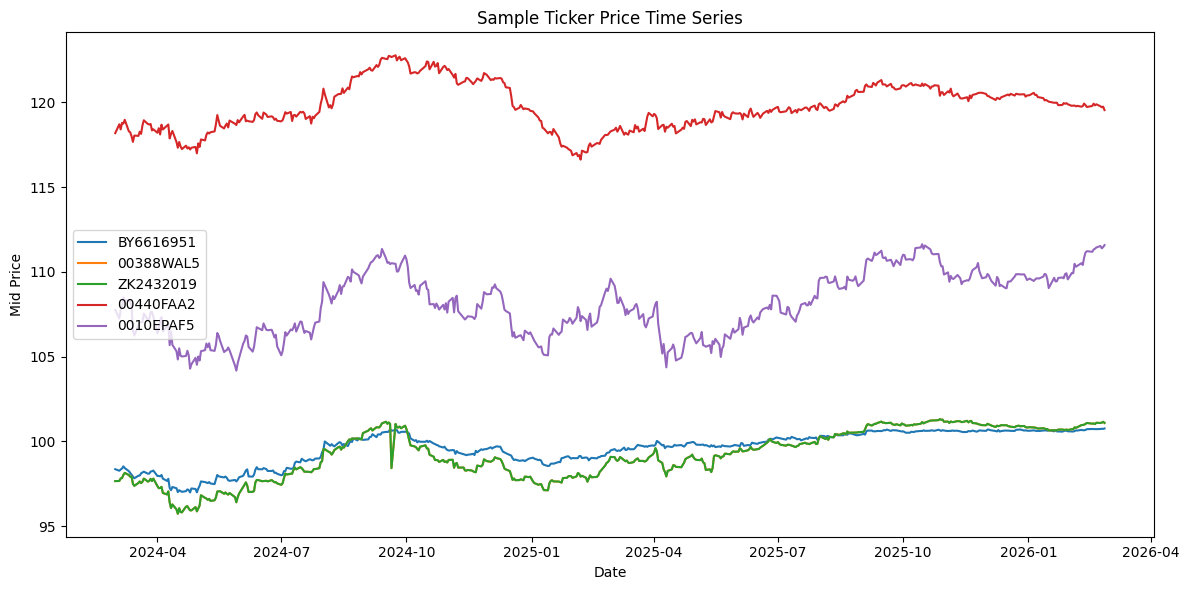

Summary statistics for tickers:
                   mean       std      min      max
BY6616951     99.594575  0.996362   96.993  100.764
00388WAL5     99.217315  1.466796   95.733  101.317
ZK2432019     99.217315  1.466796   95.733  101.317
00440FAA2    119.730046  1.343404  116.617  122.772
0010EPAF5    108.104465  1.854321  104.174  111.629
...                 ...       ...      ...      ...
96122FAA5    100.708437  1.085827   97.649  102.156
96122QAC7.1  101.792938  1.320115   98.351  103.810
96122FAC1.1  101.792938  1.320115   98.351  103.810
96122QAA1.1  100.708437  1.085827   97.649  102.156
96122FAA5.1  100.708437  1.085827   97.649  102.156

[148 rows x 4 columns]


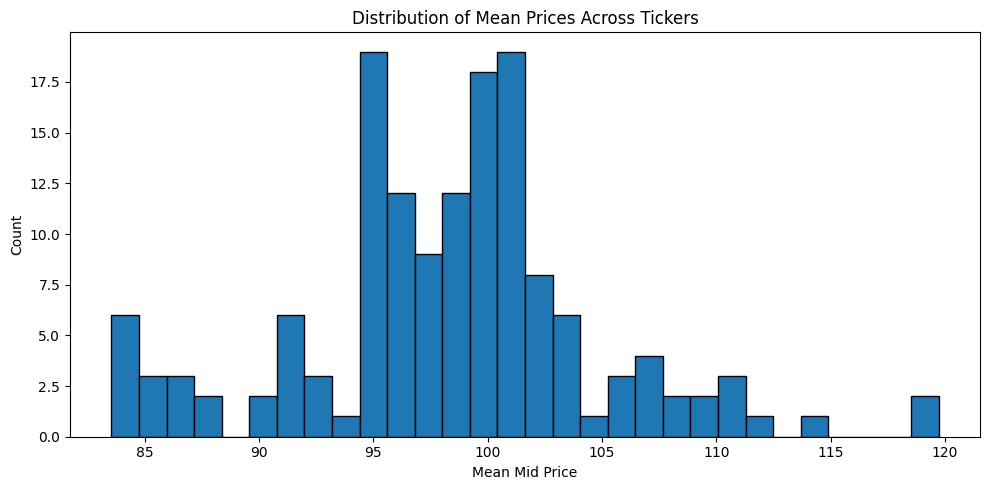

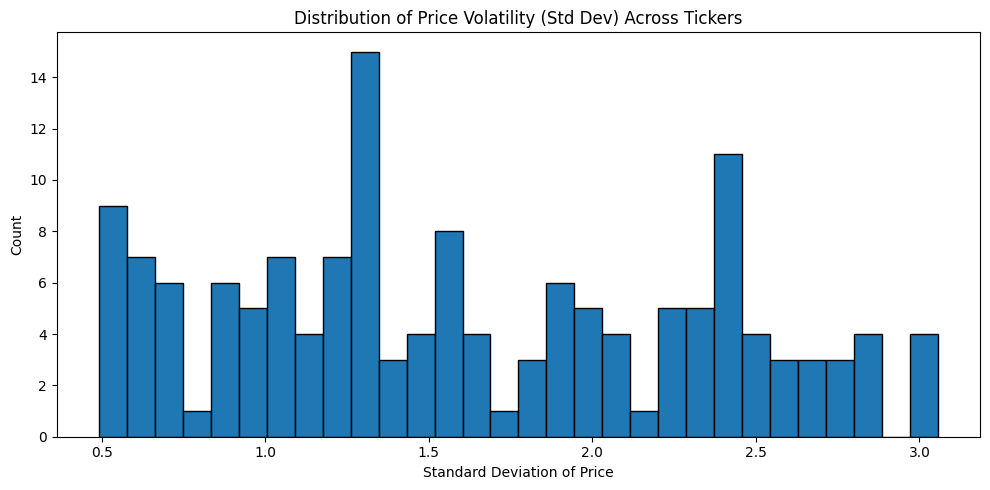

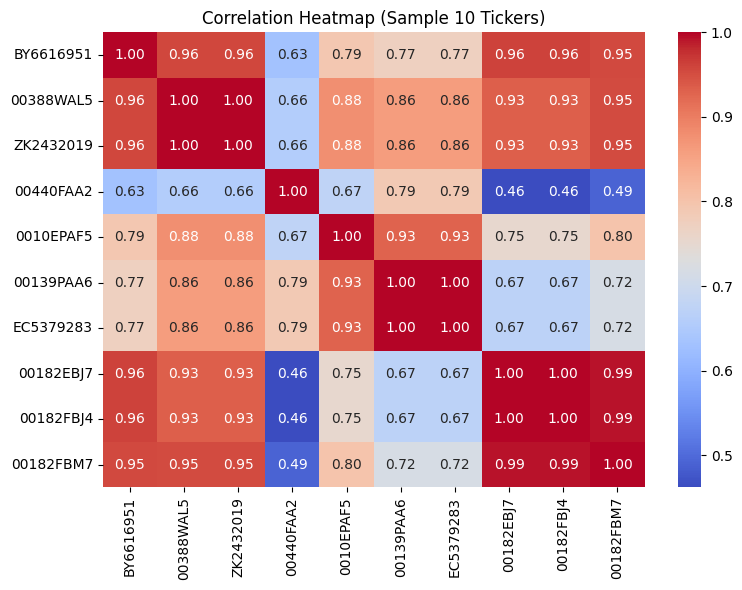

Top 10 tickers with most missing values:
BY6616951    0.0
698900AG2    0.0
6944PM2K2    0.0
717081DV2    0.0
74256LEH8    0.0
74256MEH6    0.0
74256LEP0    0.0
74256MEQ6    0.0
742718FG9    0.0
744330AA9    0.0
dtype: float64


In [213]:
# 1. Check general info and missing values
print("Price DF shape:", price_df.shape)
print("Price DF columns:", price_df.columns)
print("Missing values per column:")
print(price_df.isnull().sum())

# 2. Convert the date column to datetime and set as index if not already
price_df = price_df.copy()
if not pd.api.types.is_datetime64_any_dtype(price_df.iloc[:,0]):
    price_df.iloc[:,0] = pd.to_datetime(price_df.iloc[:,0])
price_df = price_df.set_index(price_df.columns[0])

# 3. Plot timeseries for a few tickers to visualize price evolution
sample_tickers = price_df.columns[:5]  # pick first 5, or random/sample as you prefer
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    plt.plot(price_df.index, price_df[ticker], label=ticker)
plt.legend()
plt.title('Sample Ticker Price Time Series')
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.tight_layout()
plt.show()

# 4. Plot summary statistics
summary = price_df.describe().T[['mean', 'std', 'min', 'max']]
print("Summary statistics for tickers:")
print(summary)

# 5. Plot distribution of means across all tickers
plt.figure(figsize=(10, 5))
plt.hist(price_df.mean(), bins=30, edgecolor='black')
plt.title('Distribution of Mean Prices Across Tickers')
plt.xlabel('Mean Mid Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Plot distribution of volatility (standard deviation) across all tickers
plt.figure(figsize=(10, 5))
plt.hist(price_df.std(), bins=30, edgecolor='black')
plt.title('Distribution of Price Volatility (Std Dev) Across Tickers')
plt.xlabel('Standard Deviation of Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Correlation heatmap among tickers - only for a subset due to high number
subset = price_df.columns[:10]
corr = price_df[subset].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Sample 10 Tickers)')
plt.tight_layout()
plt.show()

# 8. Identify tickers with most missing data
missing_pct = price_df.isnull().mean().sort_values(ascending=False)
print("Top 10 tickers with most missing values:")
print(missing_pct.head(10))

## Bid Sheet

In [214]:
bid_df = bid_df[cols_to_keep]

In [215]:
bid_df.head()

,Unnamed: 0,BY6616951,00388WAL5,ZK2432019,00440FAA2,0010EPAF5,00139PAA6,EC5379283,00182EBJ7,00182FBJ4,...,96122XAQ1,96122WAQ3,96122QAC7,96122FAC1,96122QAA1,96122FAA5,96122QAC7.1,96122FAC1.1,96122QAA1.1,96122FAA5.1
0,2024-03-01,98.109,97.553,97.553,117.876,107.489,109.334,109.334,94.354,94.354,...,97.943,97.943,100.346,100.346,99.313,99.313,100.346,100.346,99.313,99.313
1,2024-03-04,98.083,97.517,97.517,118.207,107.007,109.001,109.001,94.257,94.257,...,97.847,97.847,100.174,100.174,99.259,99.259,100.174,100.174,99.259,99.259
2,2024-03-05,98.151,97.711,97.711,118.169,107.368,109.199,109.199,94.470,94.470,...,98.045,98.045,100.475,100.475,99.459,99.459,100.475,100.475,99.459,99.459
3,2024-03-06,98.207,97.715,97.715,118.626,107.601,109.892,109.892,94.588,94.588,...,98.068,98.068,100.611,100.611,99.594,99.594,100.611,100.611,99.594,99.594
4,2024-03-07,98.312,97.912,97.912,118.536,108.036,109.623,109.623,94.724,94.724,...,98.205,98.205,100.833,100.833,99.717,99.717,100.833,100.833,99.717,99.717


Bid DF shape: (499, 149)
Bid DF columns: Index(['Unnamed: 0', 'BY6616951', '00388WAL5', 'ZK2432019', '00440FAA2',
       '0010EPAF5', '00139PAA6', 'EC5379283', '00182EBJ7', '00182FBJ4',
       ...
       '96122XAQ1', '96122WAQ3', '96122QAC7', '96122FAC1', '96122QAA1',
       '96122FAA5', '96122QAC7.1', '96122FAC1.1', '96122QAA1.1',
       '96122FAA5.1'],
      dtype='object', length=149)
Missing values per column:
Unnamed: 0     0
BY6616951      0
00388WAL5      0
ZK2432019      0
00440FAA2      0
              ..
96122FAA5      0
96122QAC7.1    0
96122FAC1.1    0
96122QAA1.1    0
96122FAA5.1    0
Length: 149, dtype: int64


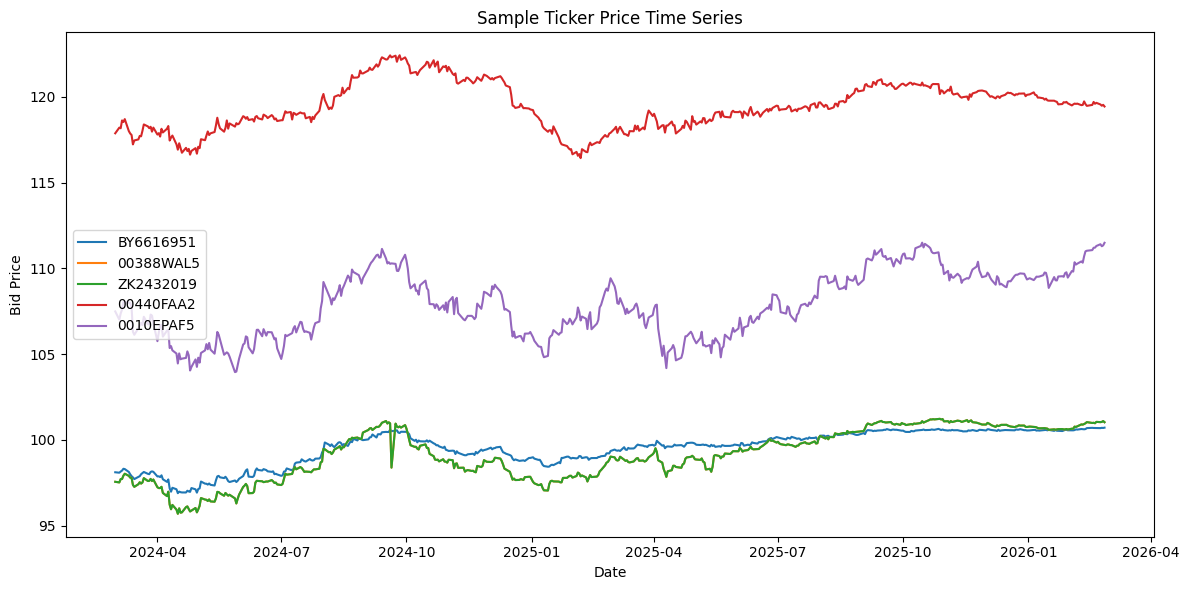

Summary statistics for tickers:
                   mean       std      min      max
BY6616951     99.504703  1.013355   96.889  100.710
00388WAL5     99.139333  1.475439   95.687  101.225
ZK2432019     99.139333  1.475439   95.687  101.225
00440FAA2    119.438741  1.351208  116.428  122.427
0010EPAF5    107.904808  1.887676  103.949  111.498
...                 ...       ...      ...      ...
96122FAA5    100.656900  1.100111   97.590  102.107
96122QAC7.1  101.745331  1.323964   98.271  103.748
96122FAC1.1  101.745331  1.323964   98.271  103.748
96122QAA1.1  100.656900  1.100111   97.590  102.107
96122FAA5.1  100.656900  1.100111   97.590  102.107

[148 rows x 4 columns]


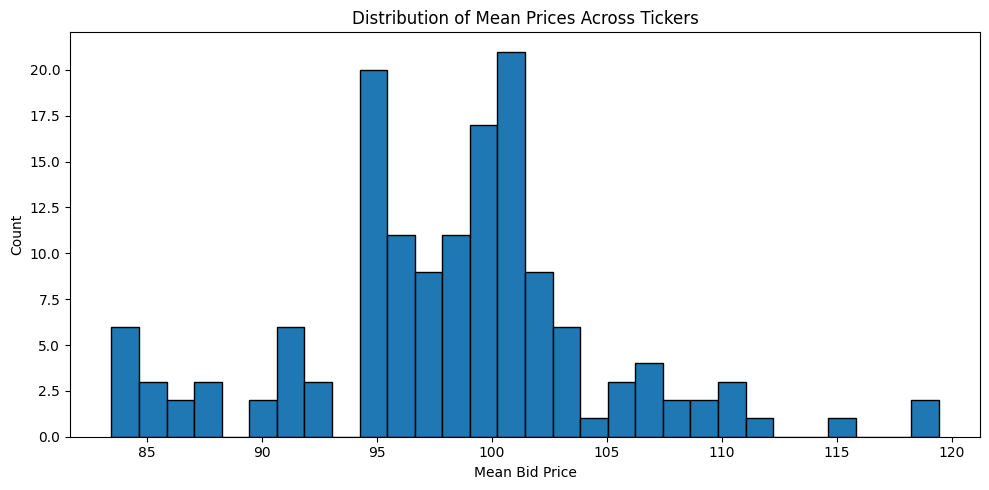

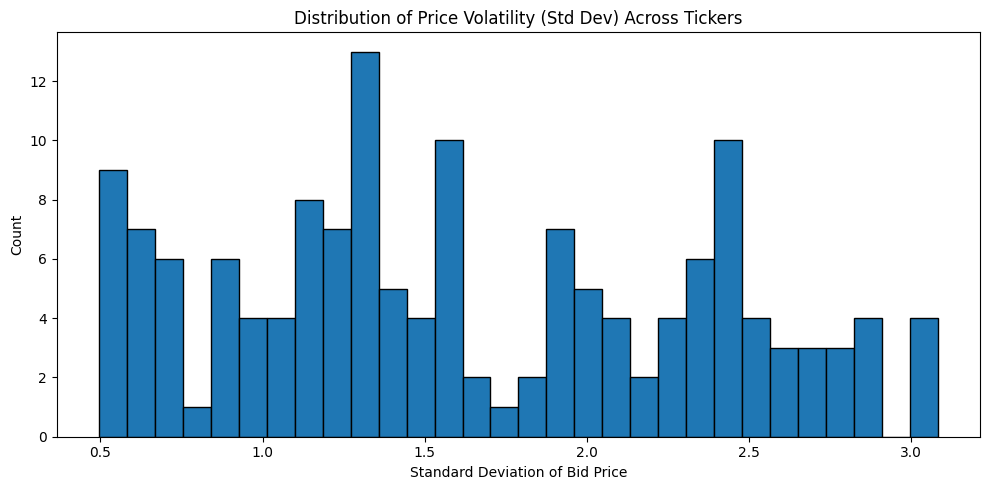

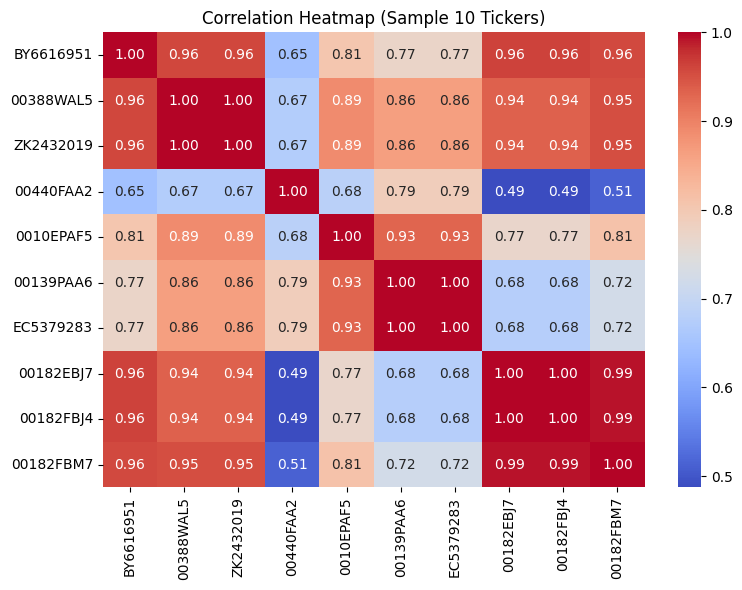

Top 10 tickers with most missing values:
BY6616951    0.0
698900AG2    0.0
6944PM2K2    0.0
717081DV2    0.0
74256LEH8    0.0
74256MEH6    0.0
74256LEP0    0.0
74256MEQ6    0.0
742718FG9    0.0
744330AA9    0.0
dtype: float64


In [216]:
# 1. Check general info and missing values
print("Bid DF shape:", bid_df.shape)
print("Bid DF columns:", bid_df.columns)
print("Missing values per column:")
print(bid_df.isnull().sum())

# 2. Convert the date column to datetime and set as index if not already
bid_df = bid_df.copy()
if not pd.api.types.is_datetime64_any_dtype(bid_df.iloc[:,0]):
    bid_df.iloc[:,0] = pd.to_datetime(bid_df.iloc[:,0])
bid_df = bid_df.set_index(bid_df.columns[0])

# 3. Plot timeseries for a few tickers to visualize price evolution
sample_tickers = bid_df.columns[:5]  # pick first 5, or random/sample as you prefer
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    plt.plot(bid_df.index, bid_df[ticker], label=ticker)
plt.legend()
plt.title('Sample Ticker Price Time Series')
plt.xlabel('Date')
plt.ylabel('Bid Price')
plt.tight_layout()
plt.show()

# 4. Plot summary statistics
summary = bid_df.describe().T[['mean', 'std', 'min', 'max']]
print("Summary statistics for tickers:")
print(summary)

# 5. Plot distribution of means across all tickers
plt.figure(figsize=(10, 5))
plt.hist(bid_df.mean(), bins=30, edgecolor='black')
plt.title('Distribution of Mean Prices Across Tickers')
plt.xlabel('Mean Bid Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Plot distribution of volatility (standard deviation) across all tickers
plt.figure(figsize=(10, 5))
plt.hist(bid_df.std(), bins=30, edgecolor='black')
plt.title('Distribution of Price Volatility (Std Dev) Across Tickers')
plt.xlabel('Standard Deviation of Bid Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Correlation heatmap among tickers - only for a subset due to high number
subset = bid_df.columns[:10]
corr = bid_df[subset].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Sample 10 Tickers)')
plt.tight_layout()
plt.show()

# 8. Identify tickers with most missing data
missing_pct = bid_df.isnull().mean().sort_values(ascending=False)
print("Top 10 tickers with most missing values:")
print(missing_pct.head(10))

## Ask Sheet

In [217]:
ask_df = ask_df[cols_to_keep]

In [218]:
ask_df.head()

,Unnamed: 0,BY6616951,00388WAL5,ZK2432019,00440FAA2,0010EPAF5,00139PAA6,EC5379283,00182EBJ7,00182FBJ4,...,96122XAQ1,96122WAQ3,96122QAC7,96122FAC1,96122QAA1,96122FAA5,96122QAC7.1,96122FAC1.1,96122QAA1.1,96122FAA5.1
0,2024-03-01,98.618,97.771,97.771,118.484,108.027,109.498,109.498,94.530,94.530,...,98.269,98.269,100.424,100.424,99.561,99.561,100.424,100.424,99.561,99.561
1,2024-03-04,98.460,97.819,97.819,119.197,107.485,109.205,109.205,94.385,94.385,...,98.141,98.141,100.232,100.232,99.443,99.443,100.232,100.232,99.443,99.443
2,2024-03-05,98.538,97.927,97.927,118.631,108.150,109.569,109.569,94.596,94.596,...,98.335,98.335,100.561,100.561,99.641,99.641,100.561,100.561,99.641,99.641
3,2024-03-06,98.603,97.961,97.961,118.942,108.221,110.036,110.036,94.696,94.696,...,98.272,98.272,100.675,100.675,99.832,99.832,100.675,100.675,99.832,99.832
4,2024-03-07,98.746,98.152,98.152,118.952,108.956,110.153,110.153,94.854,94.854,...,98.413,98.413,100.927,100.927,99.927,99.927,100.927,100.927,99.927,99.927


Ask DF shape: (499, 149)
Ask DF columns: Index(['Unnamed: 0', 'BY6616951', '00388WAL5', 'ZK2432019', '00440FAA2',
       '0010EPAF5', '00139PAA6', 'EC5379283', '00182EBJ7', '00182FBJ4',
       ...
       '96122XAQ1', '96122WAQ3', '96122QAC7', '96122FAC1', '96122QAA1',
       '96122FAA5', '96122QAC7.1', '96122FAC1.1', '96122QAA1.1',
       '96122FAA5.1'],
      dtype='object', length=149)
Missing values per column:
Unnamed: 0     0
BY6616951      0
00388WAL5      0
ZK2432019      0
00440FAA2      0
              ..
96122FAA5      0
96122QAC7.1    0
96122FAC1.1    0
96122QAA1.1    0
96122FAA5.1    0
Length: 149, dtype: int64


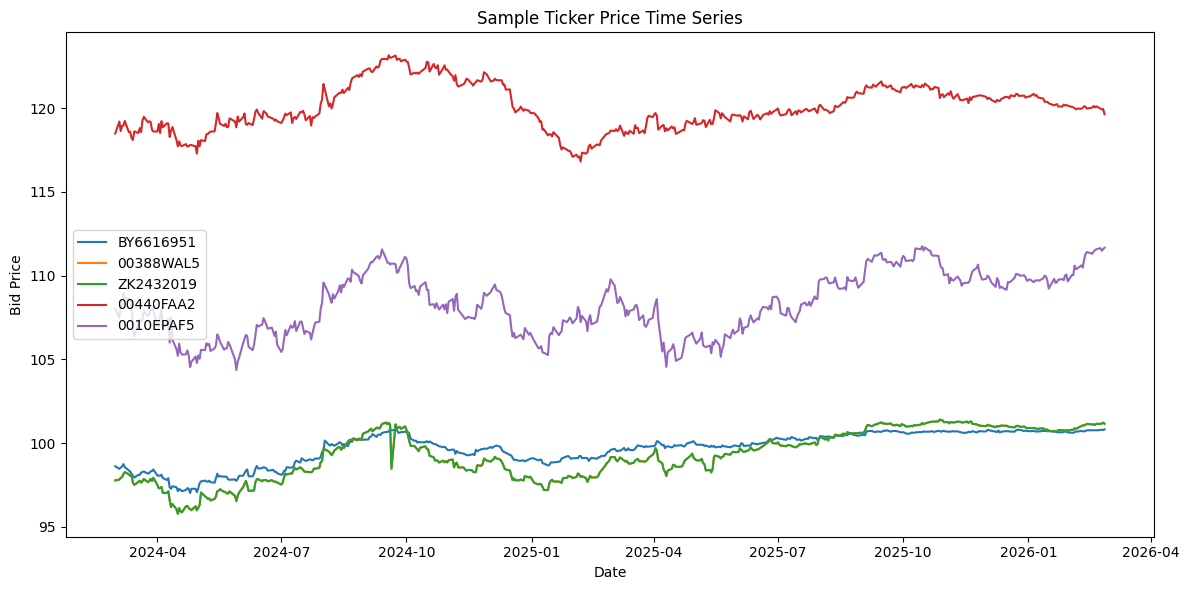

Summary statistics for tickers:
                   mean       std      min      max
BY6616951     99.684571  0.980024   97.018  100.860
00388WAL5     99.295297  1.458577   95.779  101.409
ZK2432019     99.295297  1.458577   95.779  101.409
00440FAA2    120.021351  1.341557  116.806  123.157
0010EPAF5    108.304122  1.825347  104.367  111.760
...                 ...       ...      ...      ...
96122FAA5    100.759974  1.071854   97.708  102.205
96122QAC7.1  101.840545  1.316471   98.431  103.872
96122FAC1.1  101.840545  1.316471   98.431  103.872
96122QAA1.1  100.759974  1.071854   97.708  102.205
96122FAA5.1  100.759974  1.071854   97.708  102.205

[148 rows x 4 columns]


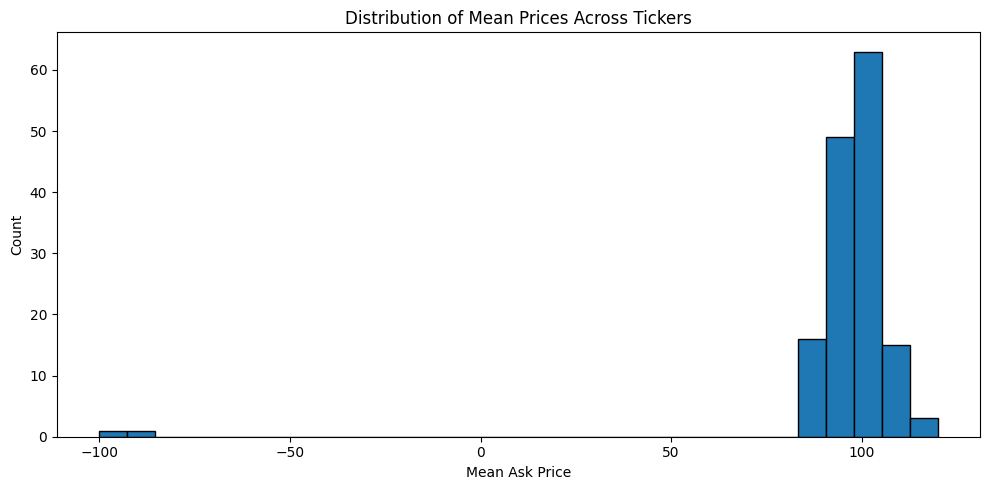

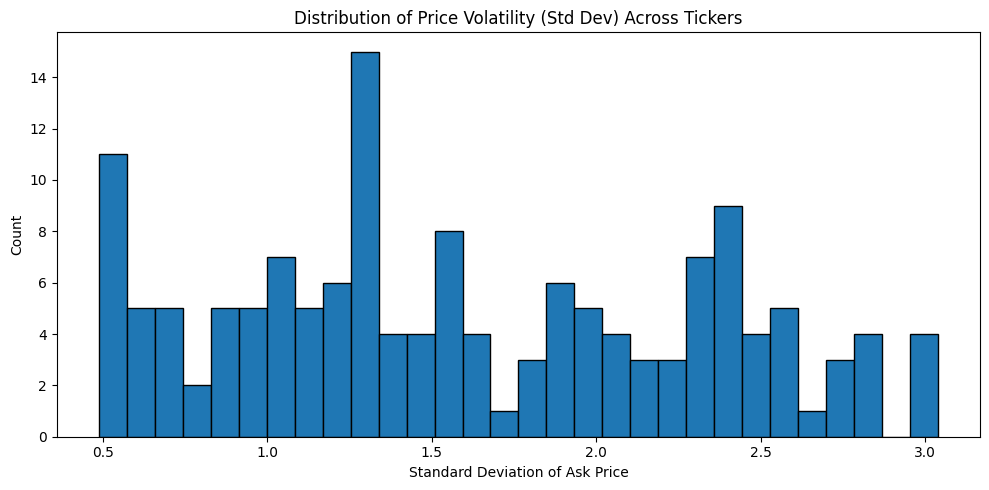

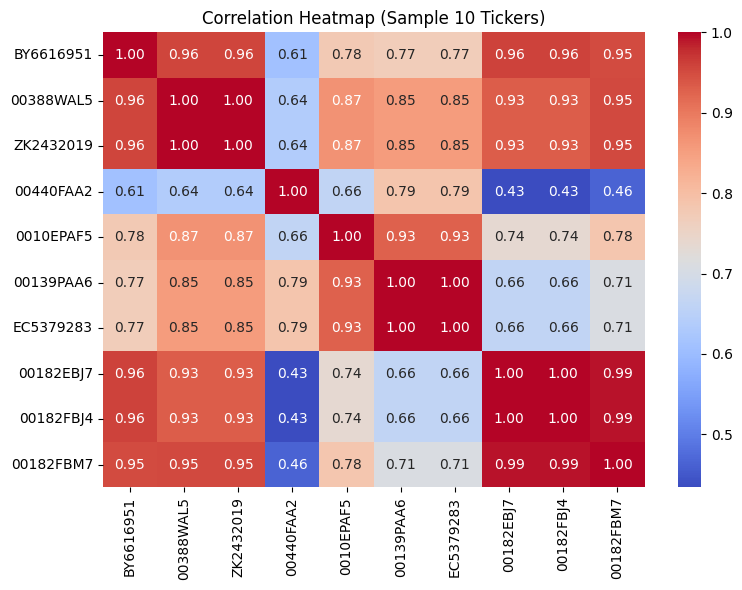

Top 10 tickers with most missing values:
ZK3662838    0.002004
191216DD9    0.002004
BY6616951    0.000000
744330AA9    0.000000
717081DV2    0.000000
74256LEH8    0.000000
74256MEH6    0.000000
74256LEP0    0.000000
74256MEQ6    0.000000
742718FG9    0.000000
dtype: float64


In [219]:
# 1. Check general info and missing values
print("Ask DF shape:", ask_df.shape)
print("Ask DF columns:", ask_df.columns)
print("Missing values per column:")
print(ask_df.isnull().sum())

# 2. Convert the date column to datetime and set as index if not already
ask_df = ask_df.copy()
if not pd.api.types.is_datetime64_any_dtype(ask_df.iloc[:,0]):
    ask_df.iloc[:,0] = pd.to_datetime(ask_df.iloc[:,0])
ask_df = ask_df.set_index(ask_df.columns[0])

# 3. Plot timeseries for a few tickers to visualize price evolution
sample_tickers = ask_df.columns[:5]  # pick first 5, or random/sample as you prefer
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    plt.plot(ask_df.index, ask_df[ticker], label=ticker)
plt.legend()
plt.title('Sample Ticker Price Time Series')
plt.xlabel('Date')
plt.ylabel('Bid Price')
plt.tight_layout()
plt.show()

# 4. Plot summary statistics
summary = ask_df.describe().T[['mean', 'std', 'min', 'max']]
print("Summary statistics for tickers:")
print(summary)

# 5. Plot distribution of means across all tickers
plt.figure(figsize=(10, 5))
plt.hist(ask_df.mean(), bins=30, edgecolor='black')
plt.title('Distribution of Mean Prices Across Tickers')
plt.xlabel('Mean Ask Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Plot distribution of volatility (standard deviation) across all tickers
plt.figure(figsize=(10, 5))
plt.hist(ask_df.std(), bins=30, edgecolor='black')
plt.title('Distribution of Price Volatility (Std Dev) Across Tickers')
plt.xlabel('Standard Deviation of Ask Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Correlation heatmap among tickers - only for a subset due to high number
subset = ask_df.columns[:10]
corr = ask_df[subset].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Sample 10 Tickers)')
plt.tight_layout()
plt.show()

# 8. Identify tickers with most missing data
missing_pct = ask_df.isnull().mean().sort_values(ascending=False)
print("Top 10 tickers with most missing values:")
print(missing_pct.head(10))